In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms,datasets
if torch.cuda.is_available():
    #device=torch.device("cpu")
    device = torch.device("cuda") 
print(f"Using device: {device}")

Using device: cuda


### Data Pre-Processing

In [3]:
transform=transforms.ToTensor()
train_dataset=datasets.MNIST(train=True,transform=transform,root="data",download=True)
test_dataset=datasets.MNIST(train=False,transform=transform,root="data",download=True)
train_loader=DataLoader(torch.utils.data.Subset(train_dataset, range(10000)),shuffle=True,batch_size=64)
test_loader=DataLoader(test_dataset,batch_size=64,shuffle=True)
x,y=(next(iter(train_loader)))
print(x.shape)
print(y.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


### Model

In [4]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1=nn.Conv2d(in_channels=1,out_channels=16,kernel_size=3,stride=1,padding=1)
        self.pool=nn.MaxPool2d(kernel_size=2)
        self.conv2=nn.Conv2d(in_channels=16,out_channels=32,kernel_size=3,stride=1,padding=1)
        self.fc=nn.Linear(7*7*32,10)
    def forward(self,x):
        x=self.conv1(x)
        #print(x.shape)
        x=torch.relu(x)
        #print(x.shape)
        x=self.pool(x)
        #print(x.shape)
        x=self.conv2(x)
        #print(x.shape)
        x=torch.relu(x)
        #print(x.shape)
        x=self.pool(x)
        #print(x.shape)
        x=torch.flatten(x,1)
        #print(x.shape)
        x=self.fc(x)
        #print(x.shape)
        return x

In [6]:
epoch=10
model=CNN()
model = model.to(device)
optimizer=torch.optim.Adam(model.parameters(),lr=0.01)
loss_fn=nn.CrossEntropyLoss()

model.train()
for i in range(epoch):
    loss=0
    for image,label in train_loader:
        image=image.to(device)
        label=label.to(device)
        model.zero_grad()
        predicted_result=model.forward(image)
        batch_loss=loss_fn(predicted_result,label)
        batch_loss.backward()
        optimizer.step()
        loss+=batch_loss.item()
    if i%2==0:
        print(loss/len(train_loader))

0.4639655593901303
0.08605879708934741
0.05904239668083751
0.0513587441873013
0.03033496466039674


torch.Size([1, 1, 28, 28])
torch.Size([1, 16, 28, 28])


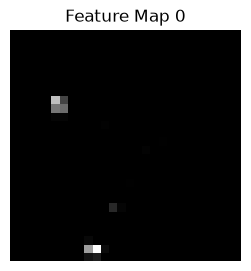

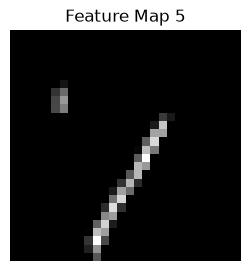

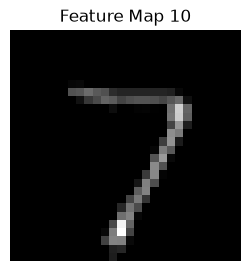

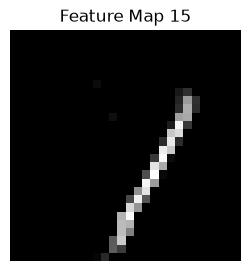

In [16]:
image, label = test_dataset[0]
image = image.unsqueeze(0)
image=image.to(device)
print(image.shape)
with torch.no_grad():
    feature_maps = model.conv1(image)
print(feature_maps.shape)
with torch.no_grad():
    feature_maps = torch.relu(feature_maps)
import matplotlib.pyplot as plt
for i in range(0,16,5):
    plt.figure(figsize=(3,3))
    plt.imshow(feature_maps[0, i].cpu(), cmap="gray")
    plt.title(f"Feature Map {i}")
    plt.axis("off")
    plt.show()

torch.Size([1, 32, 14, 14])


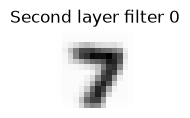

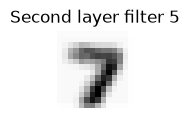

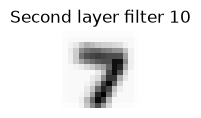

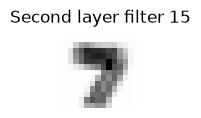

In [17]:
with torch.no_grad():
    x = model.conv1(image)
    x = torch.relu(x)
    x = model.pool(x)
    second_maps = model.conv2(x)
print(second_maps.shape)
for i in range(0,16,5):
    plt.figure(figsize=(1,1))
    plt.imshow(second_maps[0, i].cpu().numpy(),cmap="gray")
    plt.title(f"Second layer filter {i}")
    plt.axis("off")
    plt.show()